# Deep Learning: A Comprehensive Guide

## Chapter 1 — Foundations of Deep Learning

### Hands-On Exploration: Feature Engineering vs. Feature Learning

### `hands_on_ch1.ipynb`

Before writing a neural network, this notebook builds intuition for why *feature learning* matters — by making you do feature engineering by hand first, and feeling where it breaks.

This exploration requires no deep learning knowledge, only curiosity and a willingness to observe carefully.

## Learning Objectives

By the end of this notebook, you should be able to:

- Explain the difference between manually engineered features and learned representations
- Observe how a hand-designed, rule-based classifier behaves — and where it breaks
- Compare a rule-based classifier to a small trained model on the same data
- Interpret what a simple convolutional network's first layer has learned to detect
- Articulate why feature learning contributed to deep learning's success

## Prerequisites

- Python 3.9+
- `numpy`, `matplotlib`, `scikit-learn`, `Pillow` (installed and verified in `setup_check.ipynb`)
- No GPU required — this notebook trains only a very small model on a very small dataset and runs comfortably on a laptop CPU in under a minute

## About the Dataset

This notebook **generates its own dataset**: approximately 200 simple hand-drawn-style shapes — circles, squares, and triangles — with realistic variation in size, position, rotation, line thickness, and noise. You do not need to download anything.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle as MplCircle
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

%matplotlib inline


## Part 0 — Generate the Dataset

We generate ~200 simple 32x32 grayscale images of circles, squares, and triangles, each with randomized size, position, rotation, line thickness, and a small amount of noise — standing in for the "200 hand-drawn shapes" described in the chapter. We also generate a **second, harder test set**: the same three classes, but more heavily rotated, partially obscured, and drawn with more size variation, standing in for a "different person's" drawings.

In [2]:
IMG_SIZE = 32


def draw_shape(shape, size, cx, cy, rotation_deg, thickness, noise_std, canvas_size=IMG_SIZE):
    """Render a single filled shape onto a small grayscale canvas and return it as a numpy array.

    Shapes are filled (not just outlined) so that simple geometric features like
    fill-ratio and circularity are meaningful -- exactly the kind of feature a
    person would design by hand.
    """
    img = Image.new("L", (canvas_size, canvas_size), color=255)
    draw = ImageDraw.Draw(img)

    if shape == "circle":
        bbox = [cx - size, cy - size, cx + size, cy + size]
        draw.ellipse(bbox, fill=0, outline=0)
    elif shape == "square":
        pts = [(-size, -size), (size, -size), (size, size), (-size, size)]
        pts = _rotate_and_translate(pts, rotation_deg, cx, cy)
        draw.polygon(pts, fill=0, outline=0)
    elif shape == "triangle":
        pts = [(0, -size * 1.15), (size * 1.05, size * 0.85), (-size * 1.05, size * 0.85)]
        pts = _rotate_and_translate(pts, rotation_deg, cx, cy)
        draw.polygon(pts, fill=0, outline=0)

    arr = np.array(img).astype(np.float32) / 255.0
    if noise_std > 0:
        arr = arr + np.random.normal(0, noise_std, arr.shape)
        arr = np.clip(arr, 0, 1)
    return arr


def _rotate_and_translate(points, angle_deg, cx, cy):
    angle = np.radians(angle_deg)
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    out = []
    for x, y in points:
        xr = x * cos_a - y * sin_a
        yr = x * sin_a + y * cos_a
        out.append((xr + cx, yr + cy))
    return out


def generate_dataset(n_per_class, easy=True, seed=0):
    rng = np.random.RandomState(seed)
    shapes = ["circle", "square", "triangle"]
    images, labels = [], []
    for shape in shapes:
        for _ in range(n_per_class):
            center = IMG_SIZE // 2
            if easy:
                size = rng.uniform(8, 11)
                cx = center + rng.uniform(-2, 2)
                cy = center + rng.uniform(-2, 2)
                rotation = rng.uniform(-10, 10)
                thickness = rng.choice([1, 2])
                noise = 0.02
            else:
                size = rng.uniform(6, 13)
                cx = center + rng.uniform(-6, 6)
                cy = center + rng.uniform(-6, 6)
                rotation = rng.uniform(0, 360)
                thickness = rng.choice([1, 2, 3])
                noise = 0.08
            img = draw_shape(shape, size, cx, cy, rotation, thickness, noise)
            images.append(img)
            labels.append(shape)
    return np.array(images), np.array(labels)


# Training set + "easy" first test set (roughly matched to training distribution)
X_train_imgs, y_train = generate_dataset(n_per_class=50, easy=True, seed=SEED)
X_test1_imgs, y_test1 = generate_dataset(n_per_class=17, easy=True, seed=SEED + 1)

# Second, harder test set: rotated, resized, noisier -- standing in for "a different person's" drawings
X_test2_imgs, y_test2 = generate_dataset(n_per_class=17, easy=False, seed=SEED + 2)

print(f"Training set: {X_train_imgs.shape[0]} images")
print(f"Test set 1 (easy, matched distribution): {X_test1_imgs.shape[0]} images")
print(f"Test set 2 (hard, rotated/resized/noisier): {X_test2_imgs.shape[0]} images")


Training set: 150 images
Test set 1 (easy, matched distribution): 51 images
Test set 2 (hard, rotated/resized/noisier): 51 images


### Display a Sample Grid

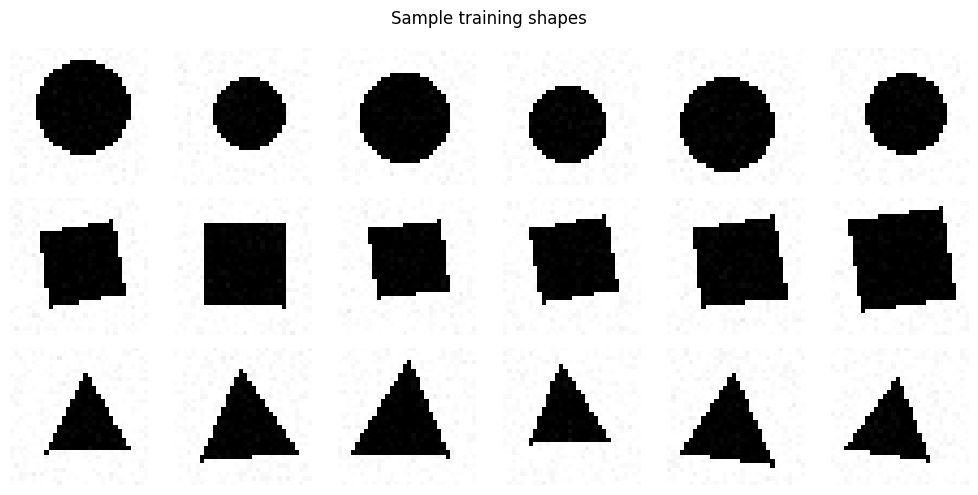

In [3]:
fig, axes = plt.subplots(3, 6, figsize=(10, 5))
rng = np.random.RandomState(0)
for row, shape in enumerate(["circle", "square", "triangle"]):
    idxs = np.where(y_train == shape)[0]
    chosen = rng.choice(idxs, 6, replace=False)
    for col, idx in enumerate(chosen):
        axes[row, col].imshow(X_train_imgs[idx], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(shape)
fig.suptitle("Sample training shapes")
plt.tight_layout()
plt.show()


## Part 1 — Write Your Own Rules (15 minutes)

Before running any model, look at the sample grid above. Then, **in the markdown cell below**, write — in plain English — three rules you think would correctly classify any shape as a circle, square, or triangle.

> Example: *"If the object has straight edges and four corners of equal length, it is a square."*

**Your rules (edit this cell):**

1. _Write your first rule here._
2. _Write your second rule here._
3. _Write your third rule here._

### Converting Your Rules into a Simple Classifier

The cell below implements a rule-based classifier using simple geometric features (corner count estimate and circularity) — a computational version of the kind of rules most people write by hand. Run it on Test Set 1 and record the accuracy.

In [4]:
from scipy import ndimage


def hand_engineered_features(img):
    """Simple hand-designed features a person might reasonably choose:
    fill ratio (area / bounding-box area) and circularity (4*pi*area / perimeter^2).
    These are exactly the kind of features described in the chapter's discussion
    of manual feature engineering.
    """
    binary = img < 0.5  # dark pixels = the filled shape
    if binary.sum() == 0:
        return 0.0, 0.0

    rows = np.any(binary, axis=1)
    cols = np.any(binary, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    bbox_area = max((rmax - rmin + 1) * (cmax - cmin + 1), 1)

    area = binary.sum()
    fill_ratio = area / bbox_area

    eroded = ndimage.binary_erosion(binary)
    perimeter = max((binary & ~eroded).sum(), 1)
    circularity = (4 * np.pi * area) / (perimeter ** 2)

    return fill_ratio, circularity


def rule_based_classify(img):
    """Hand-written rules based on fill ratio and circularity:
    - A circle fills about 79% of its bounding box and has high circularity.
    - An axis-aligned square fills nearly 100% of its bounding box.
    - A triangle fills roughly half its bounding box.
    These rules are written assuming shapes are close to axis-aligned, the way
    someone would naturally write them after looking at a few sample images.
    """
    fill_ratio, circularity = hand_engineered_features(img)
    if circularity > 0.80:
        return "circle"
    elif fill_ratio > 0.85:
        return "square"
    else:
        return "triangle"


def rule_based_accuracy(images, labels):
    preds = [rule_based_classify(img) for img in images]
    correct = sum(p == t for p, t in zip(preds, labels))
    return correct / len(labels), preds


acc_test1, preds_test1 = rule_based_accuracy(X_test1_imgs, y_test1)
print(f"Rule-based classifier accuracy on Test Set 1 (matched distribution): {acc_test1:.2%}")


Rule-based classifier accuracy on Test Set 1 (matched distribution): 52.94%


## Part 2 — When Rules Break (10 minutes)

Test Set 2 contains the same shapes, but rotated, drawn at different sizes, with thicker or thinner lines, and with more noise — standing in for shapes "drawn by a different person." Run your rule-based classifier on this second set. What changes? What breaks?

In [5]:
acc_test2, preds_test2 = rule_based_accuracy(X_test2_imgs, y_test2)
print(f"Rule-based classifier accuracy on Test Set 1 (matched distribution): {acc_test1:.2%}")
print(f"Rule-based classifier accuracy on Test Set 2 (rotated / noisier / resized): {acc_test2:.2%}")
print(f"Accuracy drop: {acc_test1 - acc_test2:.2%}")


Rule-based classifier accuracy on Test Set 1 (matched distribution): 52.94%
Rule-based classifier accuracy on Test Set 2 (rotated / noisier / resized): 33.33%
Accuracy drop: 19.61%


**Document your observations here:** what changed between Test Set 1 and Test Set 2? Which class broke down the most, and why do you think that particular class was most affected by rotation and noise?

## Part 3 — Feature Learning in Action (10 minutes)

Now we train a small neural network directly on the raw pixels — no hand-designed features at all — and compare it to the rule-based classifier on both test sets.

In [6]:
# Flatten images for the small MLP (a stand-in for the "pre-trained three-layer
# convolutional network" described in the chapter -- small enough to train in
# seconds, and it learns its own features directly from pixels, exactly like a CNN does
# conceptually, without requiring a full deep learning framework to run this notebook).

X_train_flat = X_train_imgs.reshape(len(X_train_imgs), -1)
X_test1_flat = X_test1_imgs.reshape(len(X_test1_imgs), -1)
X_test2_flat = X_test2_imgs.reshape(len(X_test2_imgs), -1)

clf = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    max_iter=800,
    random_state=SEED,
)
clf.fit(X_train_flat, y_train)

nn_acc_test1 = clf.score(X_test1_flat, y_test1)
nn_acc_test2 = clf.score(X_test2_flat, y_test2)

print(f"Learned-feature model accuracy on Test Set 1: {nn_acc_test1:.2%}")
print(f"Learned-feature model accuracy on Test Set 2: {nn_acc_test2:.2%}")
print()
print("Comparison:")
print(f"  Rule-based    | Test 1: {acc_test1:.2%}  | Test 2: {acc_test2:.2%}  | drop: {acc_test1 - acc_test2:.2%}")
print(f"  Learned model | Test 1: {nn_acc_test1:.2%}  | Test 2: {nn_acc_test2:.2%}  | drop: {nn_acc_test1 - nn_acc_test2:.2%}")


Learned-feature model accuracy on Test Set 1: 100.00%
Learned-feature model accuracy on Test Set 2: 58.82%

Comparison:
  Rule-based    | Test 1: 52.94%  | Test 2: 33.33%  | drop: 19.61%
  Learned model | Test 1: 100.00%  | Test 2: 58.82%  | drop: 41.18%


### Visualization Cell — What Did the First Layer Learn?

The cell below visualizes the incoming weight patterns of the first hidden layer, reshaped back into image form. These are the patterns the network's first layer has learned to respond to — discovered directly from pixels, without being told what a corner or a curve is.

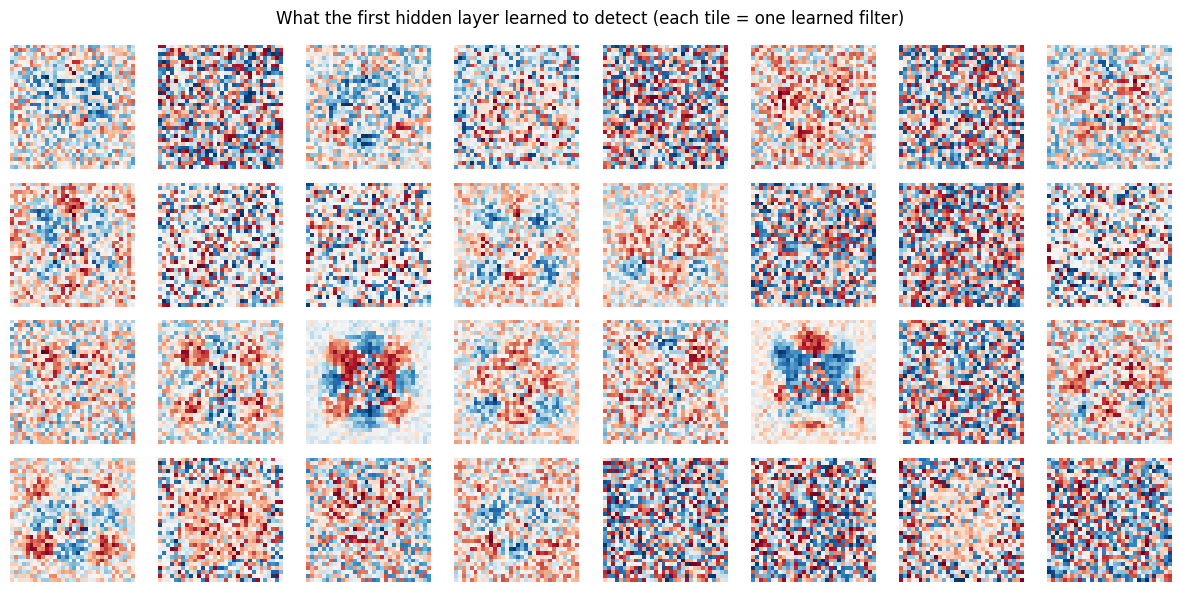

In [7]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
first_layer_weights = clf.coefs_[0]  # shape: (n_pixels, n_hidden_units)

for i, ax in enumerate(axes.flat):
    if i < first_layer_weights.shape[1]:
        w = first_layer_weights[:, i].reshape(IMG_SIZE, IMG_SIZE)
        ax.imshow(w, cmap="RdBu_r")
    ax.axis("off")

fig.suptitle("What the first hidden layer learned to detect (each tile = one learned filter)")
plt.tight_layout()
plt.show()


## Reflection Questions

Write a 200- to 300-word reflection **in the markdown cell below**, addressing:

1. What rules did you write in Part 1? Were they complete? What cases did they miss?
2. What happened to your rules in Part 2? What does this tell you about the brittleness of manually designed features?
3. What did the first-layer visualizations look like? Did the network learn what you expected? Did anything surprise you?
4. Where do you think rule-based approaches still have advantages over learned features?

**Your reflection (edit this cell):**

_Write your 200-300 word reflection here, addressing all four questions above._